In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import datetime

import torch

DATA_PATH = "E:/ML/UBC"
print(DATA_PATH)


E:/ML/UBC


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [3]:
trainList = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
trainList.head()

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


In [4]:
from sklearn.preprocessing import LabelEncoder

uniqueLabels = trainList["label"].unique()

enc = LabelEncoder()
enc.fit(uniqueLabels)
print(enc.classes_)
enc.transform(["LGSC"])

['CC' 'EC' 'HGSC' 'LGSC' 'MC']


array([3])

In [6]:
allFiles = []
stopLoop = False
for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images_rescaled")):
    for f in files:
        if f.endswith(".png"):
            allFiles.append(os.path.join(root, f))
    
len(allFiles)

538

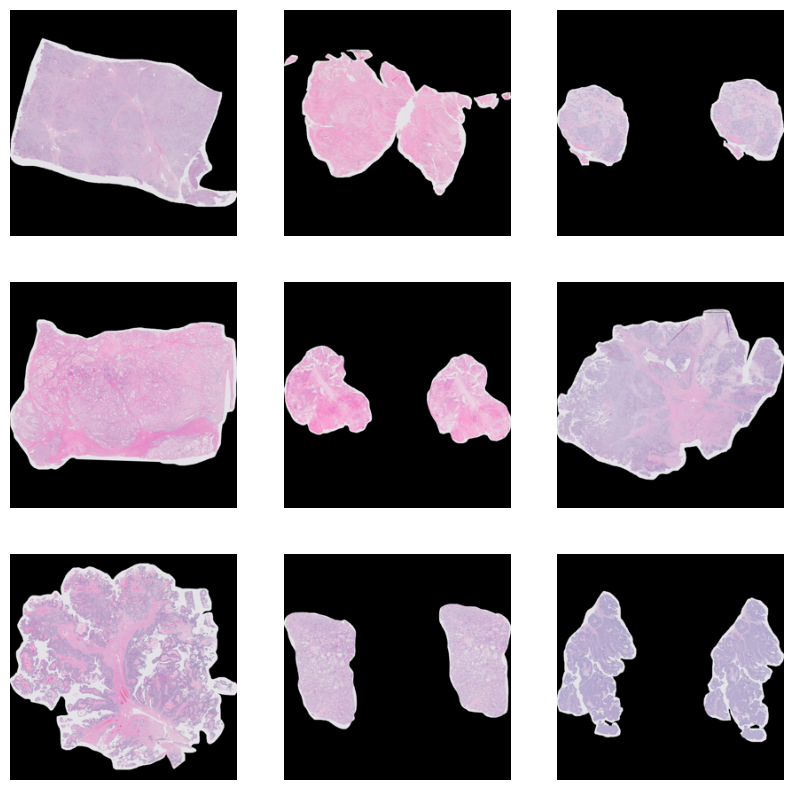

In [8]:

IMG_SIZE = (256, 256)
eps=1e-12

def readImage(path, skipResize=False):
    data = Image.open(path)
        
    w, h = data.width, data.height
    # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
    # medValue = np.median(data)

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    # data = data - np.min(data)
    # data = data * 1.0/(np.max(data)+eps)

    w, h = data.width, data.height

    # resize
    if not skipResize:
        if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
            data = np.array(data.resize(IMG_SIZE))
    
    # data = data/(np.max(data)+eps) * 2 - 1

    # data = (data * 255).astype(np.uint8)
    return data



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

In [9]:
allImages = {}
for i,filePath in enumerate(allFiles):
    im = readImage(filePath)
    id = filePath.split("\\")[-1].split(".")[0:-1][0]
    allImages[id] = im

In [22]:
TRAIN_TEST_SPLIT = 0.7

np.random.seed(56488)
# Make a deep copy such that the shuffling won't affect the patient id column in the dataset
# (skrews up the complete dataset)
trainListShuffle = trainList.copy(deep=True)
allIds = trainListShuffle["image_id"].to_numpy(copy=True)
split = int(allIds.shape[0]*TRAIN_TEST_SPLIT)
print("# Training samples:",split)
np.random.shuffle(allIds)
trainIds = allIds[0:split]
valIds = allIds[split::]

trainListIndexed= trainList.set_index("image_id")


def getData(id):
    arr = allImages[str(id)].astype(np.float32)/255.0
    # Arr3D = np.expand_dims(Arr3D, 0).astype(np.float32)

    targets = trainListIndexed.loc[id]
    label = np.array([targets["label"]])
    encLabel = enc.transform(label)
    trueLabel = np.zeros(len(enc.classes_))
    trueLabel[encLabel]=1
    return arr, encLabel.astype(np.int64)[0]


def generator():
    for trainId in trainIds:
        yield getData(trainId)


def generatorVal():
    for valId in valIds:
        yield getData(valId)

def generatorAll():
    for id in allIds:
        yield getData(id)

# Training samples: 376


In [23]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)
testInstance[1]

2

In [24]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainIds))
datasetVal = IterDataset(generatorVal, len(valIds))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [25]:
for X, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {X.shape} {X.dtype}")
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    # print(targets)
    break

Shape of X: torch.Size([32, 256, 256, 3]) torch.float32
Shape of target: torch.Size([32]) torch.int64


tensor(2)


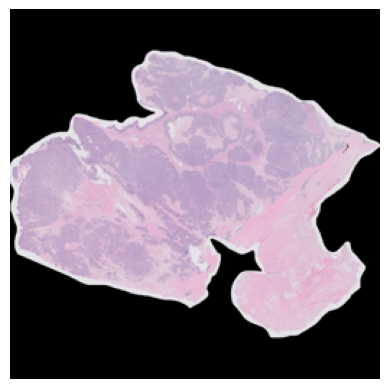

In [26]:
idx=1
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(X[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [34]:
from torch import nn
import torchinfo
from torch import nn
import torch

from modelZoo.models import Res2DModel, ResNet2DModel

Dropout=0.4
HIDDEN_DIM=128
K=1

    
# model = Res2DModel(len(enc.classes_), channels=3, name="Res2DModelPatches_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False)
model = ResNet2DModel(len(enc.classes_), channels=3, name="ResNet2DModelThumbnails_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False, useGAP=True)
from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                   Output Shape              Param #
ResNet2DModel                            [32, 5]                   --
├─convBlockResDown: 1-1                  [32, 2, 128, 128]         --
│    └─BatchNorm2d: 2-1                  [32, 3, 256, 256]         6
│    └─LeakyReLU: 2-2                    [32, 3, 256, 256]         --
│    └─Conv2d: 2-3                       [32, 3, 256, 256]         84
│    └─BatchNorm2d: 2-4                  [32, 3, 256, 256]         6
│    └─LeakyReLU: 2-5                    [32, 3, 256, 256]         --
│    └─Conv2d: 2-6                       [32, 2, 128, 128]         56
│    └─Conv2d: 2-7                       [32, 2, 128, 128]         6
│    └─BatchNorm2d: 2-8                  [32, 3, 256, 256]         6
│    └─LeakyReLU: 2-9                    [32, 3, 256, 256]         --
│    └─Conv2d: 2-10                      [32, 2, 128, 128]         56
│    └─BatchNorm2d: 2-11                 [32, 2, 128, 128]         4
│    └─LeakyReLU: 2-

In [80]:
# model_graph.visual_graph

In [35]:
loadExistingModel=False

if loadExistingModel:
    # model = simpleUnet(K=4)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4)

    checkpoint = torch.load(os.path.join("./", "ConvLSTMModelDaily2_epoch_999.pt"), map_location=device)
    # startEpoch=136
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    startEpoch = checkpoint['epoch']
    # loss = checkpoint['loss']
    model.train()
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), 5e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.998)

In [37]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import AUROC, Accuracy


LOG_INTERVAL=5
epochs = 50
EARLY_STOPPING_PATIENCE=20
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
lossFn = torch.nn.CrossEntropyLoss()


# accMetric = tf.keras.metrics.BinaryAccuracy()
accMetric = Accuracy(task="multiclass", num_classes=len(enc.classes_), average="micro").to(device)
aurocMetric = AUROC(task="multiclass", num_classes=len(enc.classes_)).to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

accMetricVal = Accuracy(task="multiclass", num_classes=len(enc.classes_), average=None).to(device)

# optimizer = torch.optim.SGD(model.parameters(), lr=0.004, momentum=0.9)

def train(dataloader, model, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (XTrain, yTrain) in enumerate(dataloader):
        XTrain = XTrain.movedim(-1,1)
        XTrain, yTrain = XTrain.to(device), yTrain.to(device)
        pred = model(XTrain)
        # targetLabel = torch.argmax(y, dim=1)
        
        loss = lossFn(pred, yTrain)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # scheduler.step()

        accMetric.update(pred, yTrain)
        aurocMetric.update(pred, yTrain)
        
        if batch % LOG_INTERVAL == 0:
            loss = loss.item()
            print("loss: {:>5f}, acc: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss, accMetric.compute(),  aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloader, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (XVal, yVal) in enumerate(dataloader):
        XVal = XVal.movedim(-1,1)
        XVal, yVal = XVal.to(device), yVal.to(device)
        predVal = model(XVal)
        # targetLabel = torch.argmax(y, dim=1)
        lossAdd = lossFn(predVal, yVal)
        loss += lossAdd.detach().cpu().numpy()
        accMetricVal.update(predVal, yVal)
        
    lossVal = loss.item()/(batch+1)
    print("Weighted Avg Cross Entropy: {:>7f}".format(lossVal))
    print("Accuracy: {:>7f}".format(torch.mean(accMetricVal.compute())))
    summary_writer.add_scalar("Val BCE", lossVal, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.flush()
    fig, ax = accMetricVal.plot()
    fig.savefig(os.path.join(DATA_PATH, "metricPlots", "accuracy_{}.png".format(epoch)))
    plt.close()
    return torch.mean(accMetricVal.compute())


bestValAcc=0.0
bestEpoch=0

for t in np.arange(startEpoch, startEpoch+epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    aurocMetric.reset()

    avgAccVal = validate(valLoader, model, t)
    accMetricVal.reset()

    if saveModel:
        model_scripted = torch.jit.script(model) # Export to TorchScript
        fileName = "{}_epoch{}_CE{:.4f}.pt".format(model.name, t, avgAccVal)
        model_scripted.save(os.path.join(DATA_PATH, fileName))
    
    #Early stopping
    if avgAccVal > bestValAcc:
        bestValAcc = avgAccVal
        bestEpoch = t
        bestWeights = model.state_dict()
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

    print("LR: {:.2E}".format(optimizer.state_dict()["param_groups"][0]["lr"]))
    
print("Done!")

Epoch 1
-------------------------------
loss: 0.291760, acc: 0.9062, AUROC: 0.9888  [    0/  376]
loss: 0.323046, acc: 0.7812, AUROC: 0.9533  [  160/  376]
loss: 0.458848, acc: 0.7812, AUROC: 0.9464  [  320/  376]
Start Validation...
Weighted Avg Cross Entropy: 3.643342
Accuracy: 0.205641
LR: 5.00E-04
Epoch 2
-------------------------------
loss: 0.419616, acc: 0.8125, AUROC: 0.9710  [    0/  376]
loss: 0.284507, acc: 0.7656, AUROC: 0.9461  [  160/  376]
loss: 0.665325, acc: 0.7642, AUROC: 0.9408  [  320/  376]
Start Validation...
Weighted Avg Cross Entropy: 5.940487
Accuracy: 0.198237
LR: 5.00E-04
Epoch 3
-------------------------------
loss: 0.826869, acc: 0.5938, AUROC: 0.9349  [    0/  376]
loss: 0.402750, acc: 0.7396, AUROC: 0.9487  [  160/  376]
loss: 0.453983, acc: 0.7472, AUROC: 0.9425  [  320/  376]
Start Validation...
Weighted Avg Cross Entropy: 4.055479
Accuracy: 0.177917
LR: 5.00E-04
Epoch 4
-------------------------------
loss: 0.594525, acc: 0.7188, AUROC: 0.9484  [    0/

In [ ]:
torch.save({
    'epoch': t,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    # 'loss': loss,
    }, os.path.join("./", model.name+"_epoch_{}.pt".format(t)))

In [20]:
# torch.save(model.state_dict, os.path.join(DATA_PATH, "convModel.pt"))

# model_scripted = torch.jit.script(model) # Export to TorchScript
# model_scripted.save('model_scripted.pt') # Save